# 2.3. Thử nghiệm mở rộng

In [52]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


## Hàm dùng để hiển thị ảnh

In [53]:
def show_plt(tittle, img):
    plt.title(tittle)
    plt.axis("off")

    if img.ndim == 2:
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)

## Load ảnh

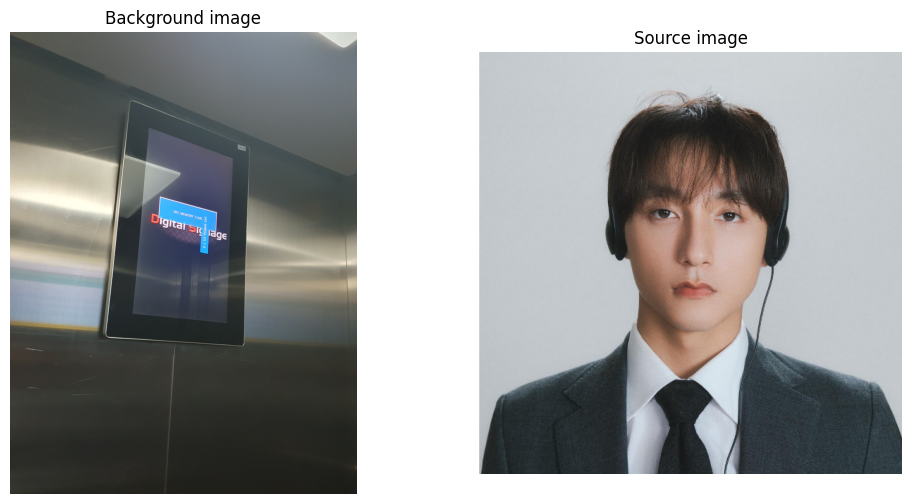

In [54]:
bg_path = "../Images/bg1.jpg"
bg = cv2.imread(bg_path, cv2.IMREAD_COLOR)

src_path = "../Images/sontung.jpg"
src = cv2.imread(src_path, cv2.IMREAD_COLOR)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
show_plt("Background image", bg)
plt.subplot(1,2,2)
show_plt("Source image", src)

## Lấy height, width của ảnh background và source

In [55]:
h_bg, w_bg = bg.shape[:2]
h_src, w_src = src.shape[:2]

print(h_bg, w_bg)
print(h_src, w_src)

4032 3024
600 600


## Hàm xác định vùng đích đến cần ánh xạ 

In [56]:
points = []

# Resize ảnh để display
bg_display = cv2.resize(bg, (640, 640))

orig_h, orig_w = bg.shape[:2]
display_h, display_w = bg_display.shape[:2]

scale_x = orig_w / display_w
scale_y = orig_h / display_h


def mouse_callback(event, x, y, flags, param):
    global bg_display

    if event == cv2.EVENT_LBUTTONDOWN:

        # chuyển về tọa độ ảnh gốc
        x_orig = int(x * scale_x)
        y_orig = int(y * scale_y)

        points.append((x_orig, y_orig))

        # vẽ trên ảnh hiển thị
        cv2.circle(bg_display, (x, y), 5, (0, 255, 0), -1)

        cv2.imshow("Background Image", bg_display)

cv2.imshow("Background Image", bg_display)

cv2.setMouseCallback("Background Image", mouse_callback)

cv2.waitKey(0)
cv2.destroyAllWindows()

# chuyển về ndarray
points = np.array(points, dtype=np.float32)
print(points)

[[1209.  844.]
 [1937. 1108.]
 [1885. 2532.]
 [1072. 2444.]]


## Hiển thị vùng đích đến cần ánh xạ

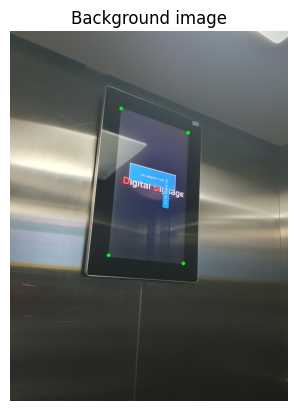

In [57]:
bg_copy = bg.copy()

for p in points:
    x, y = map(int, p)
    cv2.circle(bg_copy, (x, y), 20, (0, 255, 0), -1)

show_plt("Background image", bg_copy)

In [58]:
# các điểm của ảnh source
pts_src = np.array([
    [0, 0],
    [w_src - 1, 0],
    [w_src - 1, h_src - 1],
    [0, h_src - 1]
], dtype=np.float32)

# các điểm của ảnh background
pts_bg = np.array(points, dtype=np.float32)

# tính ma trận homography
H = cv2.getPerspectiveTransform(pts_src, pts_bg)

print("Ma trận H =\n ", H)

Ma trận H =
  [[ 1.63426989e+00 -4.00995657e-01  1.20900000e+03]
 [ 6.80359414e-01  2.27834326e+00  8.44000000e+02]
 [ 2.16267921e-04 -1.60710012e-04  1.00000000e+00]]


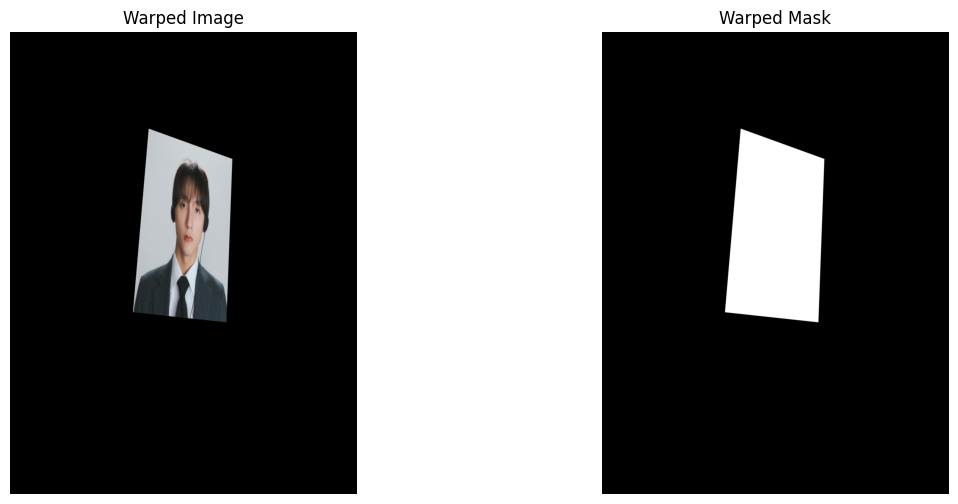

In [59]:
# biến đổi ảnh source lên vùng background
warped_src = cv2.warpPerspective(src, H, (w_bg, h_bg))

# tạo mask trắng cho ảnh source
mask_src = np.ones((h_src, w_src), dtype=np.uint8) * 255

# biến đổi mask source lên vùng background
warped_mask = cv2.warpPerspective(mask_src, H, (w_bg, h_bg))

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
show_plt("Warped Image", warped_src)
plt.subplot(1,2,2)
show_plt("Warped Mask", warped_mask)

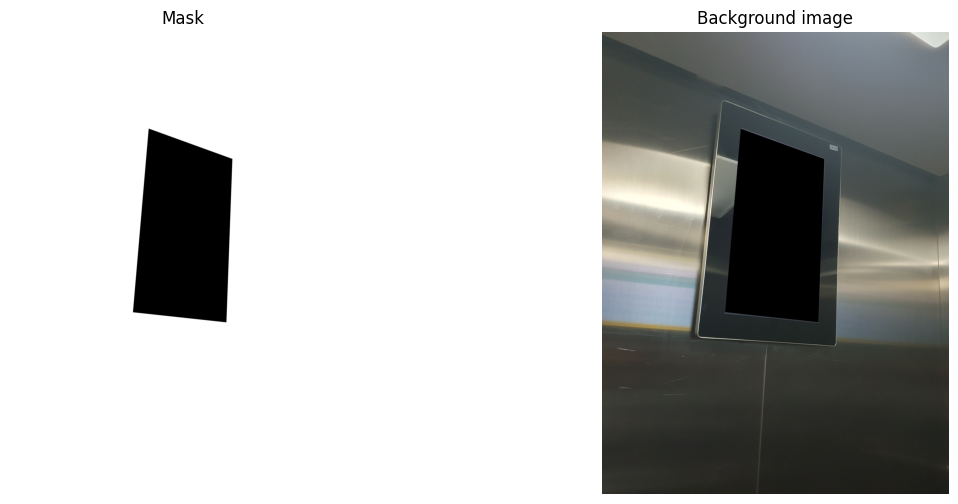

In [60]:
# mask: trắng -> đen
mask_inv = cv2.bitwise_not(warped_mask)

# xoá vùng background tại mask
bg_cleared = cv2.bitwise_and(bg, bg, mask=mask_inv)

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
show_plt("Mask", mask_inv)
plt.subplot(1,2,2)
show_plt("Background image", bg_cleared)

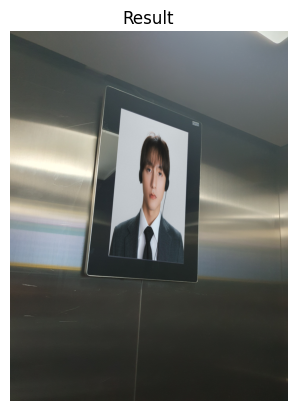

In [61]:
# ghép ảnh
result = cv2.add(bg_cleared, warped_src)

show_plt("Result", result)